In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/supermarket_sales.csv')

**dataset overview**

In [ ]:
# Display first 5 rows

df.head()

In [ ]:
df.tail()

In [ ]:
df.sample(5)

In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1]) #shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
#check missing values
miss = df.isnull().sum()
miss

In [ ]:
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage

In [ ]:
#check duplicate values
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

In [17]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates")

df.shape

Dataset Shape After Removing Duplicates


(1000, 17)

**data cleaning**

In [18]:
#rename
df.columns = df.columns.str.lower()

df.columns = df.columns.str.replace(" ", "_")

df.columns = df.columns.str.replace("%","percent")

df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='object')

In [19]:
df_clean = df.copy()

In [20]:
np.random.seed(42)
df_clean.loc[np.random.choice(df_clean.index, 20), "rating"] = np.nan
df_clean.loc[np.random.choice(df_clean.index, 15), "unit_price"] = np.nan
df_clean.loc[np.random.choice(df_clean.index, 10), "gender"] = np.nan

print("Artificial Missing Values Added.")

Artificial Missing Values Added.


In [ ]:
df_clean.isnull().sum()

In [ ]:
#visualizing missing values
plt.figure(figsize=(12,5))
sns.heatmap(df_clean.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Heatmap")

plt.show()

In [32]:
df_clean["rating"] = df_clean["rating"].fillna(df_clean["rating"].median())
df_clean["unit_cost"] = df_clean["unit_cost"].fillna(df_clean["unit_cost"].median())
df_clean["gender_customer"] = df_clean["gender_customer"].fillna(df_clean["gender_customer"].mode()[0])

In [ ]:
df_clean = df_clean.drop(columns=['unit_price', 'gender'])
display(df_clean.head())

In [ ]:
df_clean.isnull().sum()

In [36]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [37]:
df_clean.to_csv(
    "cleaned_supermarket_sales.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [38]:
#download cleaned dataset
from google.colab import files

files.download("cleaned_supermarket_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**data Visualization on original dataset as it was already cleaned**

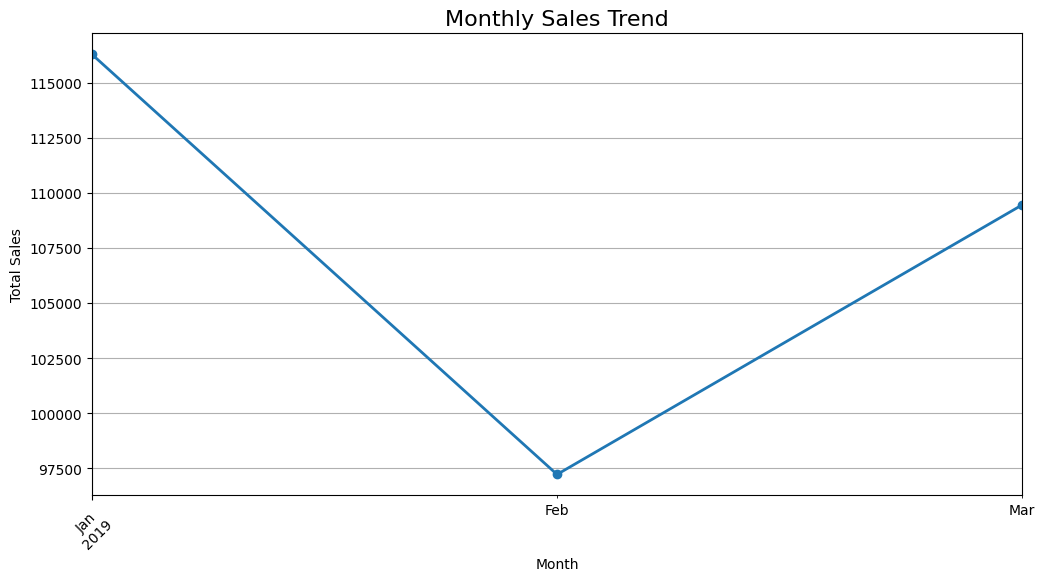

In [69]:
# Convert Order Date to datetime
df['date'] = pd.to_datetime(df['date'])
# Extract Month-Year
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['revenue'].sum()
plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o',linewidth=2)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.savefig("Monthly Sales Trend.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_592/2525166333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


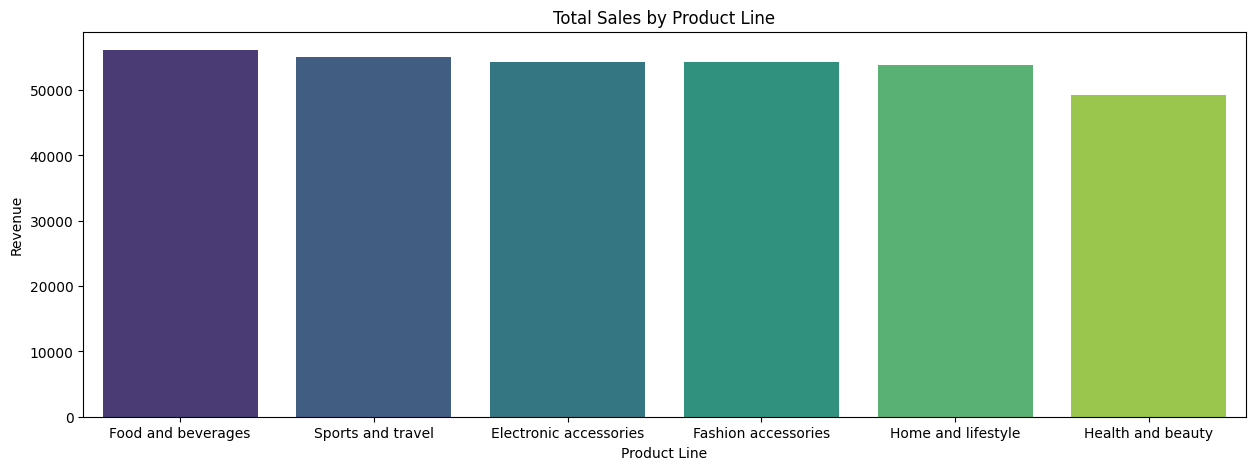

In [70]:
category_sales = df.groupby("product_line")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(15,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")

plt.savefig("Total Sales by Product Line.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_592/1948887163.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


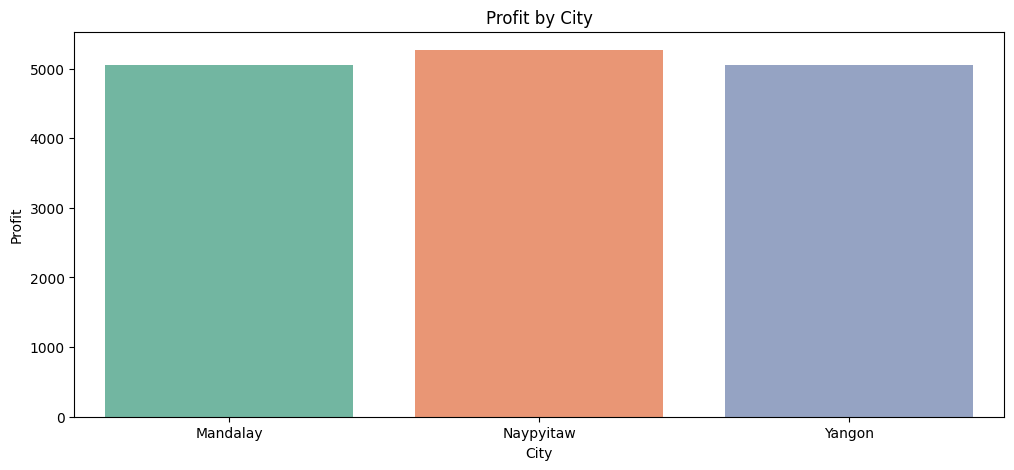

In [71]:
region_profit = df.groupby("city")["gross_income"].sum()

plt.figure(figsize=(12,5))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values,
    palette="Set2"
)

plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")

plt.savefig("profit by city.png", dpi=300, bbox_inches="tight")
plt.show()

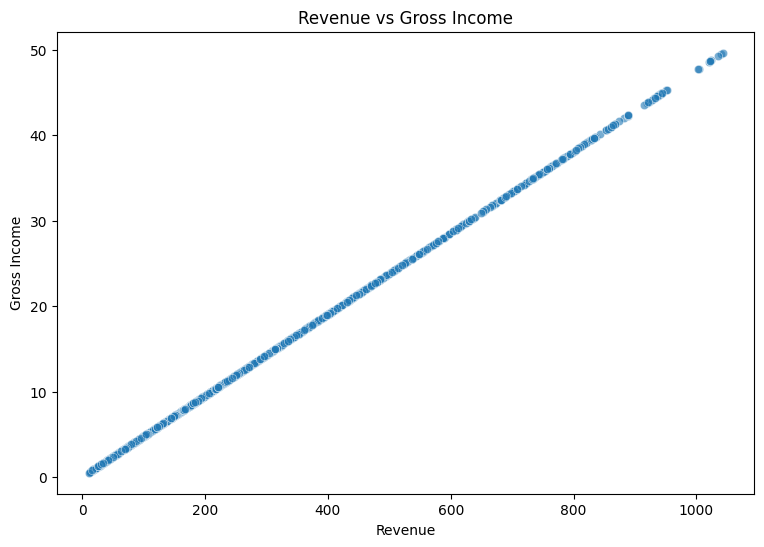

In [72]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="revenue",
    y="gross_income",
    alpha=0.6
)

plt.title("Revenue vs Gross Income")
plt.xlabel("Revenue")
plt.ylabel("Gross Income")

plt.savefig("Revenue vs Gross Income.png", dpi=300, bbox_inches="tight")
plt.show()

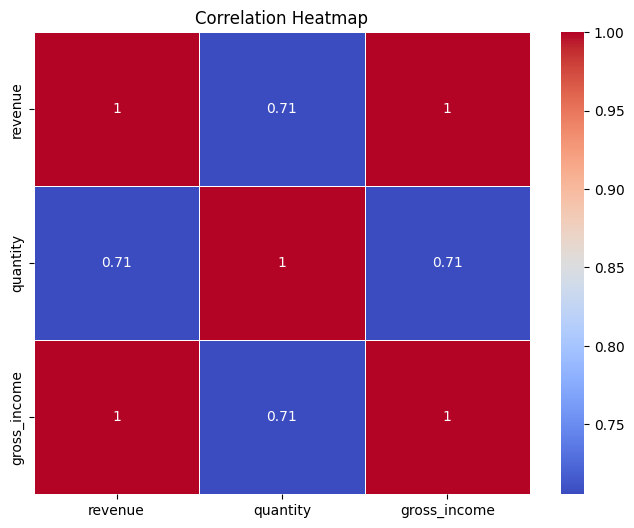

In [73]:
plt.figure(figsize=(8,6))

corr = df[["revenue","quantity","gross_income"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.savefig("Correlation Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

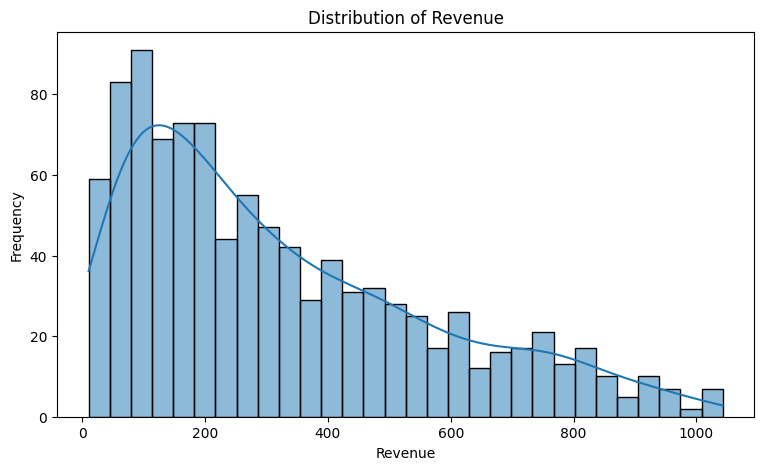

In [74]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["revenue"],
    bins=30,
    kde=True
)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.savefig("Distribution of Revenue.png", dpi=300, bbox_inches="tight")
plt.show()

In [75]:
plt.savefig("monthly_sales.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

**data cleaning and visualization completed**

In [76]:
print("=" * 60)
print("🎉 Superstore Sales Data Analysis Completed Successfully!")
print("=" * 60)
print("Dataset Cleaned ✔")
print("Visualizations Created ✔")
print("Project Ready for GitHub 🚀")
print("=" * 60)

🎉 Superstore Sales Data Analysis Completed Successfully!
Dataset Cleaned ✔
Visualizations Created ✔
Project Ready for GitHub 🚀


In [ ]:
from IPython.display import Image, display

display(Image("Correlation Heatmap.png"))

In [78]:
import os
import shutil

# Create folders
os.makedirs("Superstore-Sales-Analysis/images", exist_ok=True)
os.makedirs("Superstore-Sales-Analysis/data", exist_ok=True)
os.makedirs("Superstore-Sales-Analysis/notebook", exist_ok=True)

In [79]:
import shutil

# Move images
shutil.move("Correlation Heatmap.png", "Superstore-Sales-Analysis/images/")
shutil.move("Distribution of Revenue.png", "Superstore-Sales-Analysis/images/")
shutil.move("Monthly Sales Trend.png", "Superstore-Sales-Analysis/images/")
shutil.move("Revenue vs Gross Income.png", "Superstore-Sales-Analysis/images/")
shutil.move("Total Sales by Product Line.png", "Superstore-Sales-Analysis/images/")
shutil.move("monthly_sales.png", "Superstore-Sales-Analysis/images/")
shutil.move("profit by city.png", "Superstore-Sales-Analysis/images/")

# Move cleaned dataset
shutil.move("cleaned_supermarket_sales.csv",
            "Superstore-Sales-Analysis/data/")

'Superstore-Sales-Analysis/data/cleaned_supermarket_sales.csv'